# 02 - Build the PC researcher identity validation table

This notebook creates one report facing table for author identity
matching. The table has one row per PC researcher.

The matching rule remains simple: use exact normalized name matching
between the mapped PC name and the OpenAlex cited author table. ORCID.org
is used only as an external validation source.

## 1. Setup

In [1]:
import sys
from pathlib import Path

for candidate in [Path.cwd(), *Path.cwd().parents]:
    if (candidate / "project_setup.py").exists() and (candidate / "config" / "project_config.yaml").exists():
        if str(candidate) not in sys.path:
            sys.path.insert(0, str(candidate))
        break
else:
    raise RuntimeError(
        "Could not find the repository root. Launch Jupyter from the repo root "
        "or set PYTHONPATH to the folder containing project_setup.py."
    )

import os
import shutil
import sys
from pathlib import Path

os.environ.setdefault("ARROW_USER_SIMD_LEVEL", "NONE")

for candidate in [Path.cwd(), *Path.cwd().parents]:
    if (candidate / "config" / "project_config.yaml").exists():
        if str(candidate) not in sys.path:
            sys.path.insert(0, str(candidate))
        break

import numpy as np
import matplotlib as mpl
import matplotlib.font_manager as font_manager
import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import display

from author_matching import build_pc_people, normalize_name, short_openalex_id
from identity_validation import search_orcid_org, short_orcid
from plot import set_size
from project_setup import ensure_dirs, setup_project

setup = setup_project()
PROJECT = setup.project_folder

STEP_1_PREPARED = PROJECT / "step_1_data" / "prepared"
STEP_1_DEPENDENCIES = PROJECT / "step_1_artifacts" / "dependency_tables"
STEP_2_PREPARED = PROJECT / "step_2_data" / "prepared" / "all_papers"
STEP_3_RAW = PROJECT / "step_3_data" / "raw"
STEP_3_ARTIFACTS = PROJECT / "step_3_artifacts" / "summary_tables"
STEP_3_FIGURES = PROJECT / "step_3_artifacts" / "figures"
REPORT_FIGURES = PROJECT / "report_latex" / "figures"

ORCID_CACHE_DIR = STEP_3_RAW / "orcid_org_searches"
ensure_dirs(ORCID_CACHE_DIR, STEP_3_ARTIFACTS, STEP_3_FIGURES, REPORT_FIGURES)

PC_MEMBERS_PATH = STEP_1_PREPARED / "pc_members.parquet"
NAME_MAP_PATH = STEP_1_DEPENDENCIES / "name_map_used_for_source_comparison.csv"
REF_AUTHORS_PATH = STEP_2_PREPARED / "all_ref_authors_exploded.parquet"

IDENTITY_TABLE_OUT = STEP_3_ARTIFACTS / "pc_researcher_identity_validation.csv"
ORCID_PLOT_OUT = STEP_3_FIGURES / "orcid_match_distribution.pdf"
REPORT_ORCID_PLOT_OUT = REPORT_FIGURES / "orcid_match_distribution.pdf"

external_config = setup.project_config.get("external_validation", {})
SAMPLE_LIMIT = external_config.get("sample_limit")

print(f"Project folder: {PROJECT}")
print(f"Run mode: {setup.run_mode}")
print(f"Network allowed: {setup.allow_network}")
print(f"Sample limit: {SAMPLE_LIMIT}")

Project folder: /Users/endersari/2026-02-citations-vs-pc-memberships
Run mode: fast
Network allowed: False
Sample limit: None


## 2. Read project data

In [2]:
pc_members = pd.read_parquet(PC_MEMBERS_PATH)
ref_authors = pd.read_parquet(
    REF_AUTHORS_PATH,
    columns=["issue", "work_id", "referenced_work_id", "ref_author_name", "ref_author_id", "ref_orcid"],
)
name_map = pd.read_csv(NAME_MAP_PATH)
name_map_dict = dict(zip(name_map["name_variant"], name_map["name_canonical"]))

pc_people = build_pc_people(pc_members)
pc_people["mapped_name_for_matching"] = (
    pc_people["name"].map(name_map_dict).fillna(pc_people["name"])
)
pc_people["mapped_name_norm"] = pc_people["mapped_name_for_matching"].map(normalize_name)

if SAMPLE_LIMIT is not None:
    pc_people = pc_people.head(int(SAMPLE_LIMIT)).copy()

print(f"PC researchers: {len(pc_people):,}")
print(f"Reference-author rows: {len(ref_authors):,}")
display(pc_people.head())
display(ref_authors.head())

PC researchers: 952
Reference-author rows: 355,366


,canonical_researchr_id,name,name_variants,normalized_names,n_pc_rows,n_conferences,first_observed_pc_year,last_observed_pc_year,mapped_name_for_matching,mapped_name_norm
0,aaronbembenek,Aaron Bembenek,[Aaron Bembenek],[aaron bembenek],1,1,2025,2025,Aaron Bembenek,aaron bembenek
1,aaronstump,Aaron Stump,[Aaron Stump],[aaron stump],2,1,2019,2023,Aaron Stump,aaron stump
2,abhinavverma1,Abhinav Verma,[Abhinav Verma],[abhinav verma],1,1,2023,2023,Abhinav Verma,abhinav verma
3,adamchlipala,Adam Chlipala,[Adam Chlipala],[adam chlipala],8,3,2017,2025,Adam Chlipala,adam chlipala
4,adamwelc,Adam Welc,[Adam Welc],[adam welc],2,1,2020,2021,Adam Welc,adam welc


,issue,work_id,referenced_work_id,ref_author_name,ref_author_id,ref_orcid
0,ICFP,W2753491390,W1539916920,Przemysław Prusinkiewicz,A5086990150,0000-0002-1338-7086
1,ICFP,W2753491390,W1564690864,Aristid Lindenmayer,A5052731881,NaN
2,ICFP,W2753491390,W1966244296,John Corbit,A5079085452,0000-0002-9099-6272
3,ICFP,W2753491390,W1966244296,David J. Garbary,A5062636945,0000-0001-5126-6608
4,ICFP,W2753491390,W2000690667,Przemysław Prusinkiewicz,A5086990150,0000-0002-1338-7086


## 3. Build exact name evidence from OpenAlex

In [3]:
def unique_list(values, limit=None):
    clean = sorted({
        str(value)
        for value in values
        if pd.notna(value) and str(value).strip()
    })
    if limit is None:
        return clean
    return clean[:limit]


ref = ref_authors.copy()
ref["ref_author_id"] = ref["ref_author_id"].map(short_openalex_id)
ref["ref_orcid"] = ref["ref_orcid"].map(short_orcid)
ref["ref_norm"] = ref["ref_author_name"].map(normalize_name)
ref = ref[ref["ref_norm"] != ""].copy()
exploded_name_norms = set(ref["ref_norm"].dropna())

pc_people["original_name_norm"] = pc_people["name"].map(normalize_name)
pc_people["original_name_found_in_exploded_data"] = pc_people[
    "original_name_norm"
].isin(exploded_name_norms)
pc_people["mapped_name_found_in_exploded_data"] = pc_people[
    "mapped_name_norm"
].isin(exploded_name_norms)
pc_people["exploded_name_match_status"] = np.where(
    pc_people["original_name_found_in_exploded_data"]
    | pc_people["mapped_name_found_in_exploded_data"],
    "name_or_mapped_name_matched_with_exploded_data",
    "no_match_with_exploded_data",
)

openalex_name_index = (
    ref.groupby("ref_norm", dropna=False)
    .agg(
        n_openalex_name_rows=("ref_norm", "size"),
        n_openalex_author_id_rows=("ref_author_id", lambda x: int(x.notna().sum())),
        n_openalex_author_ids=("ref_author_id", "nunique"),
        n_openalex_citing_papers=("work_id", "nunique"),
        n_openalex_cited_works=("referenced_work_id", "nunique"),
        openalex_author_ids=("ref_author_id", lambda x: unique_list(x)),
        openalex_author_names=("ref_author_name", lambda x: unique_list(x, limit=12)),
        openalex_orcids=("ref_orcid", lambda x: unique_list(x)),
        n_openalex_orcid_rows=("ref_orcid", lambda x: int(x.notna().sum())),
        n_openalex_missing_orcid_rows=("ref_orcid", lambda x: int(x.isna().sum())),
        n_openalex_orcids_ignoring_missing=("ref_orcid", "nunique"),
    )
    .reset_index()
)

identity = pc_people.merge(
    openalex_name_index,
    left_on="mapped_name_norm",
    right_on="ref_norm",
    how="left",
)

numeric_columns = [
    "n_openalex_name_rows",
    "n_openalex_author_id_rows",
    "n_openalex_author_ids",
    "n_openalex_citing_papers",
    "n_openalex_cited_works",
    "n_openalex_orcid_rows",
    "n_openalex_missing_orcid_rows",
    "n_openalex_orcids_ignoring_missing",
]
for column in numeric_columns:
    identity[column] = identity[column].fillna(0).astype(int)

for column in ["openalex_author_ids", "openalex_author_names", "openalex_orcids"]:
    identity[column] = identity[column].map(lambda x: x if isinstance(x, list) else [])

print(f"Names found in cited authors: {(identity['n_openalex_name_rows'] > 0).sum():,}")
print(f"Names found with OpenAlex Author IDs: {(identity['n_openalex_author_id_rows'] > 0).sum():,}")
print(f"Strict one-name / one-ID matches: {(identity['n_openalex_author_ids'] == 1).sum():,}")

Names found in cited authors: 887
Names found with OpenAlex Author IDs: 877
Strict one-name / one-ID matches: 793


## 4. Query ORCID.org

In [4]:
orcid_rows = []

for _, row in identity.iterrows():
    result = search_orcid_org(
        row["mapped_name_for_matching"],
        cache_dir=ORCID_CACHE_DIR,
        allow_network=setup.allow_network,
        sleep=0.1,
        rows=1000,
    )
    candidates = [
        short_orcid(candidate)
        for candidate in result.get("candidate_orcids", [])
        if short_orcid(candidate)
    ]
    orcid_rows.append(
        {
            "canonical_researchr_id": row["canonical_researchr_id"],
            "orcid_org_query_name": row["mapped_name_for_matching"],
            "orcid_org_query_status": result.get("status"),
            "orcid_org_cache_hit": bool(result.get("cache_hit")),
            "orcid_org_candidate_count": len(candidates),
            "orcid_from_orcid_org": candidates[0] if len(candidates) == 1 else None,
            "orcid_org_candidate_examples": "; ".join(candidates[:8]),
        }
    )

orcid_org = pd.DataFrame(orcid_rows)
identity = identity.merge(orcid_org, on="canonical_researchr_id", how="left")

display(identity["orcid_org_query_status"].value_counts(dropna=False))
display(identity[["name", "mapped_name_for_matching", "orcid_org_candidate_count", "orcid_from_orcid_org"]].head())

orcid_org_query_status
fetched    952
Name: count, dtype: int64

,name,mapped_name_for_matching,orcid_org_candidate_count,orcid_from_orcid_org
0,Aaron Bembenek,Aaron Bembenek,1,0000-0002-3677-701X
1,Aaron Stump,Aaron Stump,1,0000-0002-9720-0003
2,Abhinav Verma,Abhinav Verma,21,NaN
3,Adam Chlipala,Adam Chlipala,0,NaN
4,Adam Welc,Adam Welc,1,0009-0005-0515-4994


## 5. Classify match and ORCID status

In [5]:
def one_or_none(values):
    if isinstance(values, list) and len(values) == 1:
        return values[0]
    return None


def join_values(values):
    if not isinstance(values, list) or not values:
        return ""
    return "; ".join(str(value) for value in values)


identity["openalex_name_found"] = identity["n_openalex_name_rows"] > 0
identity["openalex_author_id_found"] = identity["n_openalex_author_id_rows"] > 0
identity["openalex_id"] = identity["openalex_author_ids"].map(one_or_none)
identity["orcid_from_openalex"] = identity["openalex_orcids"].map(one_or_none)
identity["openalex_name"] = identity["openalex_author_names"].map(
    lambda values: values[0] if isinstance(values, list) and values else None
)

def match_method(row):
    if row["n_openalex_author_ids"] == 1:
        return "exact_name_one_openalex_author_id"
    if row["n_openalex_author_ids"] > 1:
        return "exact_name_multiple_openalex_author_ids"
    if row["n_openalex_name_rows"] > 0:
        return "exact_name_no_openalex_author_id"
    return "name_not_found_in_referenced_authors"


def openalex_orcid_status(row):
    if row["n_openalex_name_rows"] == 0:
        return "name_not_found"
    if row["n_openalex_orcids_ignoring_missing"] == 0:
        return "no_openalex_orcid"
    if row["n_openalex_orcids_ignoring_missing"] > 1:
        return "multiple_openalex_orcids"
    if row["n_openalex_missing_orcid_rows"] > 0:
        return "one_openalex_orcid_plus_missing"
    return "one_openalex_orcid_no_missing"


def orcid_org_comparison(row):
    if row["orcid_org_candidate_count"] != 1:
        return "orcid_org_not_unique"
    if not row["openalex_orcids"]:
        return "no_openalex_orcid_to_compare"
    if row["orcid_from_orcid_org"] in row["openalex_orcids"]:
        return "orcid_agrees"
    return "orcid_conflict"


identity["match_method"] = identity.apply(match_method, axis=1)
identity["openalex_orcid_status"] = identity.apply(openalex_orcid_status, axis=1)
identity["orcid_org_comparison"] = identity.apply(orcid_org_comparison, axis=1)
identity["ideal_openalex_case"] = (
    (identity["n_openalex_author_ids"] == 1)
    & (identity["openalex_orcid_status"] == "one_openalex_orcid_no_missing")
)

def match_confidence(row):
    if row["orcid_org_comparison"] == "orcid_conflict":
        return "RED"
    if row["match_method"] != "exact_name_one_openalex_author_id":
        return "RED"
    if row["ideal_openalex_case"] and row["orcid_org_comparison"] == "orcid_agrees":
        return "GREEN"
    return "YELLOW"


identity["match_confidence"] = identity.apply(match_confidence, axis=1)
identity["identity_layer"] = np.where(
    identity["match_method"] == "exact_name_one_openalex_author_id",
    "Layer 1",
    "Layer 2",
)

def identity_layer_reason(row):
    if row["identity_layer"] == "Layer 1":
        return "exact_name_one_openalex_author_id"
    return row["match_method"]


identity["identity_layer_reason"] = identity.apply(identity_layer_reason, axis=1)
identity["candidate_openalex_ids"] = identity["openalex_author_ids"].map(join_values)
identity["candidate_openalex_names"] = identity["openalex_author_names"].map(join_values)
identity["candidate_openalex_orcids"] = identity["openalex_orcids"].map(join_values)

display(identity["match_method"].value_counts(dropna=False))
display(identity["openalex_orcid_status"].value_counts(dropna=False))
display(identity["orcid_org_comparison"].value_counts(dropna=False))
display(identity["match_confidence"].value_counts(dropna=False))
display(identity["identity_layer"].value_counts(dropna=False))
display(identity["identity_layer_reason"].value_counts(dropna=False))
display(identity["exploded_name_match_status"].value_counts(dropna=False))

match_method
exact_name_one_openalex_author_id          793
exact_name_multiple_openalex_author_ids     84
name_not_found_in_referenced_authors        65
exact_name_no_openalex_author_id            10
Name: count, dtype: int64

openalex_orcid_status
one_openalex_orcid_no_missing      450
one_openalex_orcid_plus_missing    291
no_openalex_orcid                   88
name_not_found                      65
multiple_openalex_orcids            58
Name: count, dtype: int64

orcid_org_comparison
orcid_agrees                    452
orcid_org_not_unique            419
no_openalex_orcid_to_compare     77
orcid_conflict                    4
Name: count, dtype: int64

match_confidence
YELLOW    511
GREEN     279
RED       162
Name: count, dtype: int64

identity_layer
Layer 1    793
Layer 2    159
Name: count, dtype: int64

identity_layer_reason
exact_name_one_openalex_author_id          793
exact_name_multiple_openalex_author_ids     84
name_not_found_in_referenced_authors        65
exact_name_no_openalex_author_id            10
Name: count, dtype: int64

exploded_name_match_status
name_or_mapped_name_matched_with_exploded_data    891
no_match_with_exploded_data                        61
Name: count, dtype: int64

## 6. Save the one report facing CSV

In [6]:
output_columns = [
    "canonical_researchr_id",
    "name",
    "mapped_name_for_matching",
    "original_name_norm",
    "mapped_name_norm",
    "openalex_name",
    "openalex_id",
    "orcid_from_openalex",
    "orcid_from_orcid_org",
    "match_method",
    "match_confidence",
    "identity_layer",
    "identity_layer_reason",
    "exploded_name_match_status",
    "original_name_found_in_exploded_data",
    "mapped_name_found_in_exploded_data",
    "openalex_name_found",
    "openalex_author_id_found",
    "n_openalex_name_rows",
    "n_openalex_author_id_rows",
    "n_openalex_author_ids",
    "n_openalex_citing_papers",
    "n_openalex_cited_works",
    "n_openalex_orcids_ignoring_missing",
    "n_openalex_orcid_rows",
    "n_openalex_missing_orcid_rows",
    "openalex_orcid_status",
    "orcid_org_candidate_count",
    "orcid_org_comparison",
    "orcid_org_query_status",
    "orcid_org_candidate_examples",
    "ideal_openalex_case",
    "candidate_openalex_ids",
    "candidate_openalex_names",
    "candidate_openalex_orcids",
    "n_pc_rows",
    "n_conferences",
    "first_observed_pc_year",
    "last_observed_pc_year",
]

identity_table = identity[output_columns].sort_values("name").reset_index(drop=True)

if IDENTITY_TABLE_OUT.exists() and not setup.overwrite_artifacts:
    print(f"Keeping existing artifact: {IDENTITY_TABLE_OUT.relative_to(PROJECT)}")
else:
    identity_table.to_csv(IDENTITY_TABLE_OUT, index=False)
    print(f"Wrote {IDENTITY_TABLE_OUT.relative_to(PROJECT)}: {identity_table.shape}")

display(identity_table.head())

Wrote step_3_artifacts/summary_tables/pc_researcher_identity_validation.csv: (952, 39)


,canonical_researchr_id,name,mapped_name_for_matching,original_name_norm,mapped_name_norm,openalex_name,openalex_id,orcid_from_openalex,orcid_from_orcid_org,match_method,...,orcid_org_query_status,orcid_org_candidate_examples,ideal_openalex_case,candidate_openalex_ids,candidate_openalex_names,candidate_openalex_orcids,n_pc_rows,n_conferences,first_observed_pc_year,last_observed_pc_year
0,aaronbembenek,Aaron Bembenek,Aaron Bembenek,aaron bembenek,aaron bembenek,Aaron Bembenek,NaN,0000-0002-3677-701X,0000-0002-3677-701X,exact_name_multiple_openalex_author_ids,...,fetched,0000-0002-3677-701X,False,A5007064313; A5008144113,Aaron Bembenek,0000-0002-3677-701X,1,1,2025,2025
1,aaronstump,Aaron Stump,Aaron Stump,aaron stump,aaron stump,Aaron Stump,A5072489480,0000-0002-9720-0003,0000-0002-9720-0003,exact_name_one_openalex_author_id,...,fetched,0000-0002-9720-0003,True,A5072489480,Aaron Stump,0000-0002-9720-0003,2,1,2019,2023
2,abhinavverma1,Abhinav Verma,Abhinav Verma,abhinav verma,abhinav verma,Abhinav Verma,A5101988843,0000-0002-9820-8285,NaN,exact_name_one_openalex_author_id,...,fetched,0000-0003-0796-1915; 0000-0001-8876-0394; 0000...,True,A5101988843,Abhinav Verma,0000-0002-9820-8285,1,1,2023,2023
3,adamchlipala,Adam Chlipala,Adam Chlipala,adam chlipala,adam chlipala,Adam Chlipala,A5078100439,0000-0001-7085-9417,NaN,exact_name_one_openalex_author_id,...,fetched,,False,A5078100439,Adam Chlipala,0000-0001-7085-9417,8,3,2017,2025
4,adamwelc,Adam Welc,Adam Welc,adam welc,adam welc,Adam Welc,A5078668785,0009-0005-0515-4994,0009-0005-0515-4994,exact_name_one_openalex_author_id,...,fetched,0009-0005-0515-4994,True,A5078668785,Adam Welc,0009-0005-0515-4994,2,1,2020,2021


## 7. Plot ORCID validation distribution

This figure summarizes the ORCID.org validation signal used in the
report. The left panel shows how many ORCID.org candidates are returned
by name. The right panel focuses on Layer 1 researchers and compares
OpenAlex ORCID evidence with ORCID.org when possible.

Wrote step_3_artifacts/figures/orcid_match_distribution.pdf
Copied to report_latex/figures/orcid_match_distribution.pdf


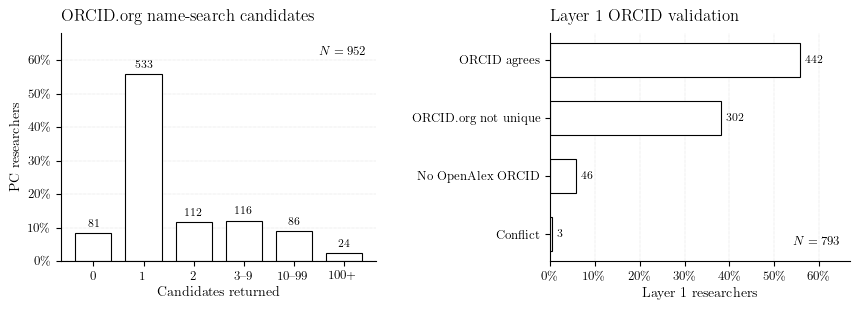

In [7]:
font_path = PROJECT / "fonts" / "LinLibertine_R.ttf"
if font_path.exists():
    font_prop = font_manager.FontProperties(fname=font_path)
    font_family = font_prop.get_name()
else:
    font_family = "serif"

mpl.rcParams.update({
    "axes.titlesize": 12,
    "axes.labelsize": 10,
    "font.size": 10,
    "legend.fontsize": 9,
    "xtick.labelsize": 9,
    "ytick.labelsize": 9,
    "font.family": font_family,
    "text.usetex": True,
})

candidate_labels = ["0", "1", "2", "3--9", "10--99", "100+"]

def candidate_bucket(count):
    if count == 0:
        return "0"
    if count == 1:
        return "1"
    if count == 2:
        return "2"
    if count <= 9:
        return "3--9"
    if count <= 99:
        return "10--99"
    return "100+"

candidate_bin = identity_table["orcid_org_candidate_count"].map(candidate_bucket)
candidate_dist = (
    candidate_bin.value_counts()
    .reindex(candidate_labels, fill_value=0)
    .rename_axis("candidate_bin")
    .reset_index(name="n")
)
candidate_dist["share"] = candidate_dist["n"] / len(identity_table)

layer1 = identity_table[identity_table["identity_layer"] == "Layer 1"].copy()
comparison_labels = {
    "orcid_agrees": "ORCID agrees",
    "orcid_org_not_unique": "ORCID.org not unique",
    "no_openalex_orcid_to_compare": "No OpenAlex ORCID",
    "orcid_conflict": "Conflict",
}
comparison_order = list(comparison_labels)
comparison_dist = (
    layer1["orcid_org_comparison"]
    .value_counts()
    .reindex(comparison_order, fill_value=0)
    .rename_axis("comparison")
    .reset_index(name="n")
)
comparison_dist["label"] = comparison_dist["comparison"].map(comparison_labels)
comparison_dist["share"] = comparison_dist["n"] / len(layer1)

fig, axes = plt.subplots(
    1,
    2,
    figsize=(8.6, 3.0),
    gridspec_kw={"width_ratios": [1.05, 1.0]},
)

left = axes[0]
bars = left.bar(
    candidate_dist["candidate_bin"],
    candidate_dist["share"],
    color="white",
    edgecolor="black",
    linewidth=0.8,
    width=0.72,
)
for bar, row in zip(bars, candidate_dist.itertuples(index=False)):
    if row.n == 0:
        continue
    left.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.012,
        f"{row.n}",
        ha="center",
        va="bottom",
        fontsize=8,
    )
left.set_title("ORCID.org name-search candidates", loc="left", pad=8)
left.set_xlabel("Candidates returned")
left.set_ylabel("PC researchers")
left.set_ylim(0, max(candidate_dist["share"].max() * 1.22, 0.1))
left.yaxis.set_major_formatter(mpl.ticker.PercentFormatter(xmax=1.0, decimals=0))
left.grid(axis="y", ls=":", linewidth=0.35, color="0.75")
left.text(
    0.97,
    0.94,
    rf"$N = {len(identity_table)}$",
    transform=left.transAxes,
    ha="right",
    va="top",
    fontsize=9,
)

right = axes[1]
comparison_dist = comparison_dist.iloc[::-1].reset_index(drop=True)
bars = right.barh(
    comparison_dist["label"],
    comparison_dist["share"],
    color="white",
    edgecolor="black",
    linewidth=0.8,
    height=0.58,
)
for bar, row in zip(bars, comparison_dist.itertuples(index=False)):
    if row.n == 0:
        continue
    right.text(
        bar.get_width() + 0.012,
        bar.get_y() + bar.get_height() / 2,
        f"{row.n}",
        ha="left",
        va="center",
        fontsize=8,
    )
right.set_title("Layer 1 ORCID validation", loc="left", pad=8)
right.set_xlabel("Layer 1 researchers")
right.set_ylabel("")
right.set_xlim(0, max(comparison_dist["share"].max() * 1.20, 0.1))
right.xaxis.set_major_formatter(mpl.ticker.PercentFormatter(xmax=1.0, decimals=0))
right.grid(axis="x", ls=":", linewidth=0.35, color="0.75")
right.text(
    0.97,
    0.06,
    rf"$N = {len(layer1)}$",
    transform=right.transAxes,
    ha="right",
    va="bottom",
    fontsize=9,
)

for ax in axes:
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.set_axisbelow(True)

fig.tight_layout(w_pad=2.4)
set_size(fig, size=(8.6, 3.1))

if ORCID_PLOT_OUT.exists() and not setup.overwrite_artifacts:
    print(f"Keeping existing figure: {ORCID_PLOT_OUT.relative_to(PROJECT)}")
else:
    fig.savefig(ORCID_PLOT_OUT, bbox_inches="tight")
    print(f"Wrote {ORCID_PLOT_OUT.relative_to(PROJECT)}")

if (not REPORT_ORCID_PLOT_OUT.exists()) or setup.overwrite_artifacts:
    shutil.copyfile(ORCID_PLOT_OUT, REPORT_ORCID_PLOT_OUT)
    print(f"Copied to {REPORT_ORCID_PLOT_OUT.relative_to(PROJECT)}")

plt.show()

## 8. Notes for the report

The table
distinguishes exact name presence, unique OpenAlex Author IDs, OpenAlex
ORCID ambiguity, and ORCID.org agreement. The confidence labels are simple: green for externally validated ideal matches, yellow
for strict matches with incomplete external evidence, and red for names
that remain unmatched, ambiguous, or conflicting.